# Vehicle Detection Inference Pipeline

This notebook demonstrates the **DTAN-based vehicle detection algorithm** for Distributed Acoustic Sensing (DAS) data.

## Pipeline Overview

1. **Load & Preprocess** HDF5 DAS data (bandpass filter, spatial decimation, energy normalization)
2. **Run DTAN Model** to align channels temporally
3. **Compute GLRT** (Generalized Likelihood Ratio Test) to detect vehicle presence
4. **Extract Detection Intervals** and estimate vehicle speeds

## How Detection Works

A vehicle passing over the fiber creates a **correlated pattern** across adjacent channels with a **time delay** proportional to speed. The DTAN model aligns these channels, and if they correlate well after alignment, a vehicle is present.

## Processing Modes

- **single_window**: Process one 28s window (fast, but ignores most of recording)
- **sliding_hop**: Process overlapping 28s windows with 50% hop (slower, covers full recording)

In [741]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Fiber-specific preprocessing settings (must match training)
# channels_range: raw HDF5 channel indices to extract for this fiber
# channel_start/end: which decimated channels to analyze (after spatial_decimation)
FIBERS = {
    'carros': {
        'channels_range': [0, 2829],       # Raw channels: 0-14.4km (2829 ch)
        'filter_freqs': [0.3, 2.0],        # Bandpass filter Hz (vehicle frequency band)
        'filter_order': 4,
        'spatial_decimation': 3,           # 2829 -> 943 channels
        'channel_start': 400,              # 456
        'channel_end': 900,                # 556
    },
    'mathis': {
        'channels_range': [2830, 8257],    # Raw channels: 20.3-48.0km (5427 ch)
        'filter_freqs': [0.3, 2.0],
        'filter_order': 4,
        'spatial_decimation': 3,           # 5427 -> 1809 channels
        'channel_start': 0,                # Analyze full fiber
        'channel_end': 1809,
    },
    'promenade': {
        'channels_range': [8258, 15952],   # Raw channels: 48.5-87.8km (7694 ch)
        'filter_freqs': [0.3, 2.0],
        'filter_order': 4,
        'spatial_decimation': 3,           # 7694 -> 2564 channels
        'channel_start': 0,                # Analyze full fiber
        'channel_end': 2564,
    },
}

CONFIG = {
    # Paths
    'hdf5_data_path': '/Users/milo/Documents/SequoIA/services/pipeline/experiments/test_data',
    'reference_dir': '../11_newmodel_remake/reference',
    'model_checkpoint': 'allignment_parameters_16_02_2026_fullSet_28s.pth',

    # Time range (HHMMSS format)
    'start_time': '082106',
    'end_time': '082226',

    # Fiber selection
    'fiber': 'carros',

    # Temporal downsampling (125Hz -> ~10.4Hz)
    'downsample_factor': 12,

    # Preprocessing
    'common_mode_removal': True,   # Remove spatially-coherent noise (recommended)
    'cmr_method': 'median',        # 'median' (robust) or 'mean' (faster)
    'energy_normalize': True,      # Equalize channel energy

    # Model parameters (must match training)
    'Nch': 9,                  # Adjacent channels per window
    'window_seconds': 28,      # Window duration

    # Detection parameters
    'corr_threshold': 500,     # Per-pair GLRT threshold for forward pass (500 seem to be working pretty well)
    'glrt_window': 20,
    'min_speed': 20,           # Valid speed range (km/h)
    'max_speed': 120,

    # Bidirectional detection
    'bidirectional': True,              # Enable detection in both directions
    'corr_threshold_reverse': None,     # Threshold for reverse pass (None = same as forward)

    # Processing mode: 'single_window' or 'sliding_hop'
    # sliding_hop: overlapping windows, covers full recording
    # single_window: one 28s window, faster but partial coverage
    'processing_mode': 'sliding_hop',
    'hop_fraction': 0.5,       # Hop as fraction of window (0.5 = 50% overlap, 0.25 = 75% overlap)
    'time_start_s': 30,        # Start time for single_window mode

    # Vehicle counting
    'enable_counting': True,           # Enable vehicle counting
    'counting_mode': 'lambda',         # 'lambda' (peak detection) or 'dl' (MLP model)
    'counting_model_path': 'models/vehicle_counting_model.pt',           # Relative to reference_dir
    'counting_features_path': 'mean_std_features_adapted_sectionwise.csv',  # Relative to reference_dir
    'classify_threshold_factor': 10.0,  # Factor for car/truck classification (visualize_data uses 40000/4000 = 10x)
}

FIBER = FIBERS[CONFIG['fiber']]

# Compute thresholds
threshold_fwd = CONFIG['corr_threshold'] * (CONFIG['Nch'] - 1)
threshold_rev = (CONFIG['corr_threshold_reverse'] or CONFIG['corr_threshold']) * (CONFIG['Nch'] - 1)

print(f"Configuration:")
print(f"  Fiber: {CONFIG['fiber']}")
print(f"  Raw channel range: {FIBER['channels_range']} ({FIBER['channels_range'][1] - FIBER['channels_range'][0]} channels)")
print(f"  After decimation: {(FIBER['channels_range'][1] - FIBER['channels_range'][0]) // FIBER['spatial_decimation']} channels")
print(f"  Analyzing: channels {FIBER['channel_start']}-{FIBER['channel_end']} ({FIBER['channel_end'] - FIBER['channel_start']} channels)")
print(f"  Processing mode: {CONFIG['processing_mode']}")
if CONFIG['processing_mode'] == 'sliding_hop':
    print(f"  Hop fraction: {CONFIG['hop_fraction']} ({int(CONFIG['hop_fraction']*100)}% hop, {int((1-CONFIG['hop_fraction'])*100)}% overlap)")
print(f"  Common mode removal: {CONFIG['common_mode_removal']} ({CONFIG['cmr_method']})")
print(f"  Energy normalize: {CONFIG['energy_normalize']}")
print(f"  Bidirectional: {CONFIG['bidirectional']}")
print(f"  Forward threshold: {CONFIG['corr_threshold']} x {CONFIG['Nch']-1} = {threshold_fwd}")
if CONFIG['bidirectional']:
    rev_thr = CONFIG['corr_threshold_reverse'] or CONFIG['corr_threshold']
    print(f"  Reverse threshold: {rev_thr} x {CONFIG['Nch']-1} = {threshold_rev}")
print(f"  Vehicle counting: {CONFIG['enable_counting']} ({CONFIG['counting_mode']} mode)")

Configuration:
  Fiber: carros
  Raw channel range: [0, 2829] (2829 channels)
  After decimation: 943 channels
  Analyzing: channels 400-900 (500 channels)
  Processing mode: sliding_hop
  Hop fraction: 0.5 (50% hop, 50% overlap)
  Common mode removal: True (median)
  Energy normalize: True
  Bidirectional: True
  Forward threshold: 500 x 8 = 4000
  Reverse threshold: 500 x 8 = 4000
  Vehicle counting: True (lambda mode)



Loading fiber: carros
Found 1 files in time range 082106 to 082106
Data shape per file (reference): (16026 channels, 1250 samples)
Original samples per file (reference): 1250
Downsample factor: 12
Samples after downsampling: 105
Requested channel range: 0 to 2829


100%|██████████| 1/1 [00:00<00:00, 13.79it/s]


Applying spatial decimation (stride-based):
  Original channels: 2829
  Decimation stride: 3 (pick every 3th channel)
  Decimated channels: 943
  Decimated data shape: (943, 105)
  Updated gauge length: 15.38 m
Loaded data shape: (943, 105)
Loaded dates shape: (105,)
Gauge: 15.3846153846
Number of channels: 943
Sampling frequency: 10.416666666666666
Done !



Loading fiber: mathis
Found 1 files in time range 082106 to 082106
Data shape per file (reference): (16026 channels, 1250 samples)
Original samples per file (reference): 1250
Downsample factor: 12
Samples after downsampling: 105
Requested channel range: 2830 to 8257


100%|██████████| 1/1 [00:00<00:00,  7.71it/s]



Applying spatial decimation (stride-based):
  Original channels: 5427
  Decimation stride: 3 (pick every 3th channel)
  Decimated channels: 1809
  Decimated data shape: (1809, 105)
  Updated gauge length: 15.38 m
Loaded data shape: (1809, 105)
Loaded dates shape: (105,)
Gauge: 15.3846153846
Number of channels: 1809
Sampling frequency: 10.416666666666666
Done !

Loading fiber: promenade
Found 1 files in time range 082106 to 082106
Data shape per file (reference): (16026 channels, 1250 samples)
Original samples per file (reference): 1250
Downsample factor: 12
Samples after downsampling: 105
Requested channel range: 8258 to 15952


100%|██████████| 1/1 [00:00<00:00,  5.62it/s]



Applying spatial decimation (stride-based):
  Original channels: 7694
  Decimation stride: 3 (pick every 3th channel)
  Decimated channels: 2565
  Decimated data shape: (2565, 105)
  Updated gauge length: 15.38 m
Loaded data shape: (2565, 105)
Loaded dates shape: (105,)
Gauge: 15.3846153846
Number of channels: 2565
Sampling frequency: 10.416666666666666
Done !


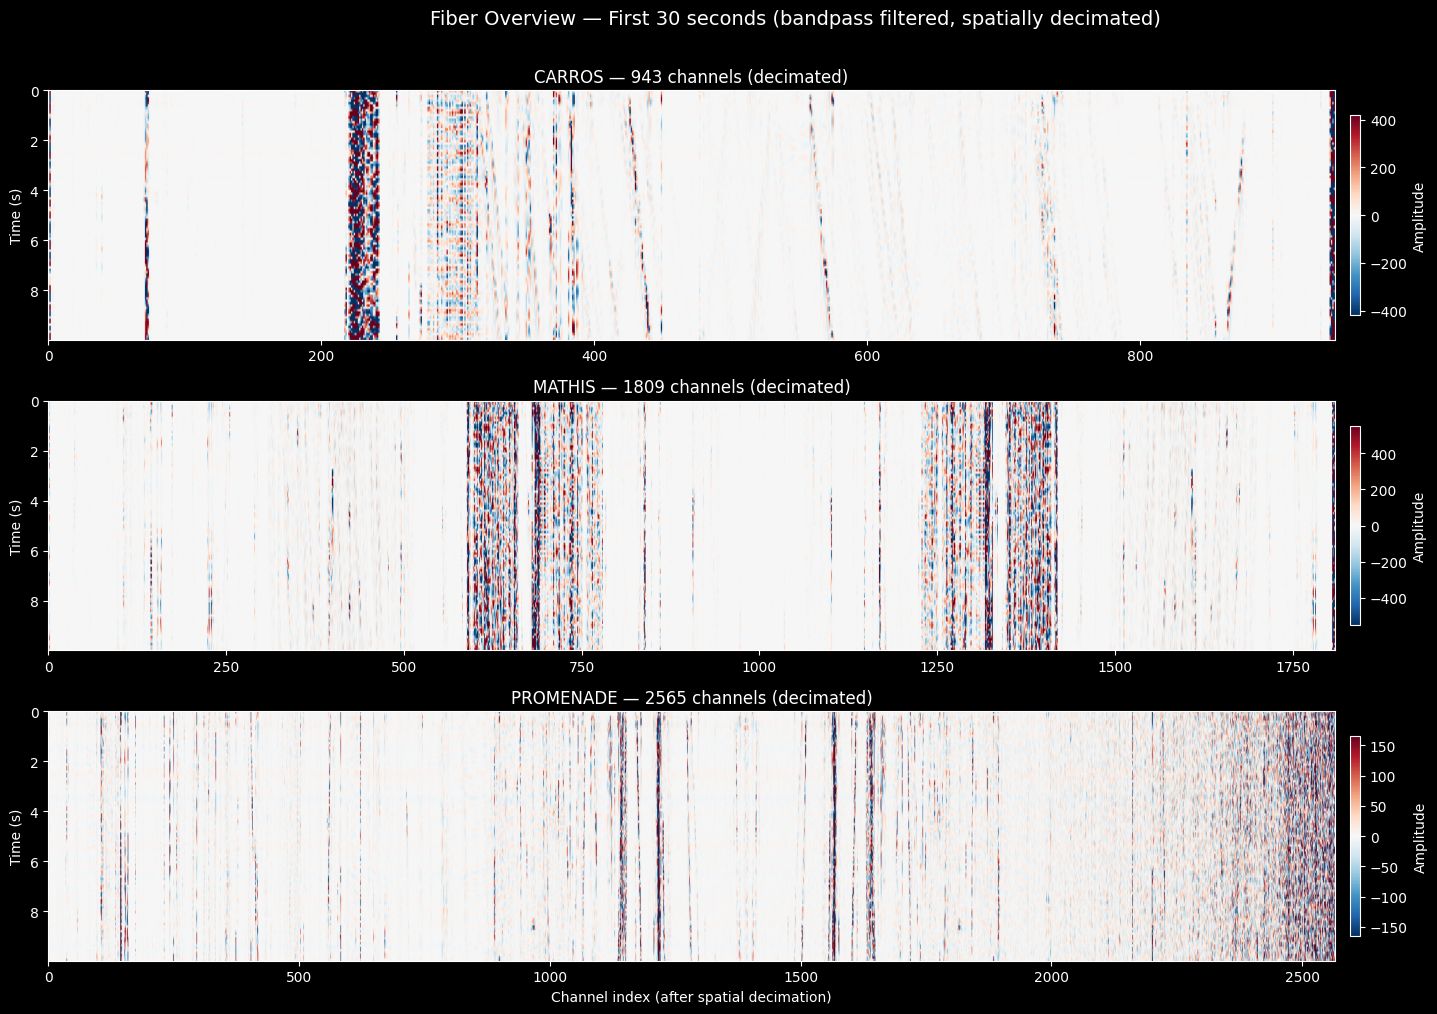

Note: This overview uses full fiber range. Main analysis uses channel_start/channel_end from CONFIG.


In [742]:
# =============================================================================
# FIBER OVERVIEW: Waterfall plots for all 3 fibers (first 30s)
# =============================================================================
# Quick visual overview of data characteristics across the full fiber span

import sys, os
import numpy as np
import matplotlib.pyplot as plt

# Add reference modules to path (needed for data loading)
ref_dir = os.path.abspath(CONFIG['reference_dir'])
if ref_dir not in sys.path:
    sys.path.insert(0, ref_dir)

from synthetic_data_DAS_generator import functions

# Calculate relative widths based on channel count
fiber_names = list(FIBERS.keys())
channel_counts = [(FIBERS[f]['channels_range'][1] - FIBERS[f]['channels_range'][0]) // FIBERS[f]['spatial_decimation'] 
                  for f in fiber_names]
max_channels = max(channel_counts)

# Create stacked subplots with proportional widths
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

for idx, fiber_name in enumerate(fiber_names):
    fiber_cfg = FIBERS[fiber_name]
    ax = axes[idx]
    
    # Load this fiber's data (just first file for speed)
    fiber_config_temp = {
        fiber_name: {
            'channels_range': fiber_cfg['channels_range'],
            'filter_freqs': fiber_cfg['filter_freqs'],
            'filter_order': fiber_cfg['filter_order'],
            'spatial_decimation_factor': fiber_cfg['spatial_decimation'],
            'center_data': True,
        }
    }
    
    try:
        fibers_temp = functions.read_filter_downsample_hdf5_DAS_data_multifiber(
            hdf5_data_path=CONFIG['hdf5_data_path'],
            start_time=CONFIG['start_time'],
            end_time=CONFIG['start_time'],  # Just first file
            fiber_config=fiber_config_temp,
            down_sample_factor=CONFIG['downsample_factor'],
            gauge=5.1282051282,
            original_fs=125,
        )
        
        fiber_data = fibers_temp[fiber_name]
        data = np.float32(fiber_data['data'])
        fs_temp = fiber_data['fs']
        
        # First 30 seconds (or all available)
        n_samples_30s = min(int(30 * fs_temp), data.shape[1])
        data_30s = data[:, :n_samples_30s]
        
        # Center the data
        data_30s = data_30s - data_30s.mean(axis=1, keepdims=True)
        
        # Plot waterfall
        vmax = 2 * data_30s.std()
        time_axis = np.arange(n_samples_30s) / fs_temp
        n_channels = data_30s.shape[0]
        
        # Channel axis (decimated channel indices)
        ch_start = 0
        ch_end = n_channels
        
        im = ax.imshow(data_30s.T, aspect='auto',
                       extent=[ch_start, ch_end, time_axis[-1], time_axis[0]],
                       cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        
        ax.set_ylabel('Time (s)')
        ax.set_title(f'{fiber_name.upper()} — {n_channels} channels (decimated)')
        plt.colorbar(im, ax=ax, label='Amplitude', shrink=0.8, pad=0.01)
        
        # Only show x-label on bottom plot
        if idx == len(fiber_names) - 1:
            ax.set_xlabel('Channel index (after spatial decimation)')
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error loading {fiber_name}:\n{str(e)[:50]}', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{fiber_name.upper()} (failed)')

plt.suptitle('Fiber Overview — First 30 seconds (bandpass filtered, spatially decimated)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Note: This overview uses full fiber range. Main analysis uses channel_start/channel_end from CONFIG.")

In [743]:
# =============================================================================
# LOAD & PREPROCESS HDF5 DATA
# =============================================================================

import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt

# Add reference modules to path
ref_dir = os.path.abspath(CONFIG['reference_dir'])
if ref_dir not in sys.path:
    sys.path.insert(0, ref_dir)

from synthetic_data_DAS_generator import functions
from synthetic_data_DAS_generator.functions import DTAN
from modules.speed_vehicules import SpeedVehicules

# Build fiber config for data loading
fiber_config = {
    CONFIG['fiber']: {
        'channels_range': FIBER['channels_range'],
        'filter_freqs': FIBER['filter_freqs'],
        'filter_order': FIBER['filter_order'],
        'spatial_decimation_factor': FIBER['spatial_decimation'],
        'center_data': True,
    }
}

# Load and preprocess: bandpass filter, spatial decimation, temporal downsample
fibers = functions.read_filter_downsample_hdf5_DAS_data_multifiber(
    hdf5_data_path=CONFIG['hdf5_data_path'],
    start_time=CONFIG['start_time'],
    end_time=CONFIG['end_time'],
    fiber_config=fiber_config,
    down_sample_factor=CONFIG['downsample_factor'],
    gauge=5.1282051282,  # Original channel spacing (m)
    original_fs=125,     # Original sample rate (Hz)
)

# Extract data for selected fiber
fiber = fibers[CONFIG['fiber']]
data = np.float32(fiber['data'])  # Shape: (n_channels, n_samples)
gauge = fiber['gauge']            # Updated gauge after decimation (~15.4m)
fs = fiber['fs']                  # Updated sample rate (~10.4 Hz)

# Select channel range for analysis
selected_data = data[FIBER['channel_start']:FIBER['channel_end'], :]

print(f"Data loaded:")
print(f"  Shape: {selected_data.shape} (channels × samples)")
print(f"  Sample rate: {fs:.2f} Hz")
print(f"  Gauge length: {gauge:.2f} m")
print(f"  Duration: {selected_data.shape[1]/fs:.1f} s")


Loading fiber: carros
Found 9 files in time range 082106 to 082226
Data shape per file (reference): (16026 channels, 1250 samples)
Original samples per file (reference): 1250
Downsample factor: 12
Samples after downsampling: 105
Requested channel range: 0 to 2829


100%|██████████| 9/9 [00:00<00:00, 10.67it/s]


Applying spatial decimation (stride-based):
  Original channels: 2829
  Decimation stride: 3 (pick every 3th channel)
  Decimated channels: 943
  Decimated data shape: (943, 945)
  Updated gauge length: 15.38 m
Loaded data shape: (943, 945)
Loaded dates shape: (945,)
Gauge: 15.3846153846
Number of channels: 943
Sampling frequency: 10.416666666666666
Done !
Data loaded:
  Shape: (500, 945) (channels × samples)
  Sample rate: 10.42 Hz
  Gauge length: 15.38 m
  Duration: 90.7 s


In [744]:
# =============================================================================
# COMMON MODE REMOVAL (Optional)
# =============================================================================
# Remove spatially-coherent noise by subtracting the spatial median/mean
# at each time step. This removes noise that affects all channels equally
# (e.g., environmental vibrations, instrument drift).

def remove_common_mode(data, method='median'):
    """Remove common mode noise from DAS data.

    Args:
        data: 2D array (channels, time)
        method: 'median' (robust to outliers) or 'mean' (faster)

    Returns:
        Data with common mode subtracted
    """
    if method == 'median':
        common_mode = np.median(data, axis=0, keepdims=True)
    else:
        common_mode = np.mean(data, axis=0, keepdims=True)
    return data - common_mode

if CONFIG.get('common_mode_removal', False):
    selected_data_before_cmr = selected_data.copy()
    selected_data = remove_common_mode(selected_data, method=CONFIG.get('cmr_method', 'median'))

    # Show effect
    std_before = np.std(selected_data_before_cmr)
    std_after = np.std(selected_data)
    print(f"Common mode removal applied ({CONFIG.get('cmr_method', 'median')}):")
    print(f"  Std before: {std_before:.2e}")
    print(f"  Std after:  {std_after:.2e}")
    print(f"  Reduction:  {100 * (1 - std_after/std_before):.1f}%")
else:
    selected_data_before_cmr = None
    print("Common mode removal: DISABLED")

# =============================================================================
# ENERGY NORMALIZATION (Optional)
# =============================================================================
# Scale each channel to have equal energy, so weak vehicles aren't missed
# and the GLRT focuses on correlation patterns rather than raw amplitude.

def normalize_channel_energy(data):
    """Normalize each channel to have the same total energy."""
    data_norm = data.copy()
    
    # Center each channel (remove DC offset)
    mean = np.mean(data_norm, axis=1, keepdims=True)
    data_norm = data_norm - mean
    
    # Compute and equalize energy per channel
    channel_energy = np.sum(np.square(data_norm), axis=1)
    mean_energy = np.mean(channel_energy)
    
    for i in range(data_norm.shape[0]):
        if channel_energy[i] > 0:
            scale = np.sqrt(mean_energy / channel_energy[i])
            data_norm[i] = data_norm[i] * scale
    
    return data_norm

# Apply normalization if enabled
if CONFIG['energy_normalize']:
    selected_data_before_norm = selected_data.copy()
    selected_data = normalize_channel_energy(selected_data)
    
    # Verify: energy std should drop dramatically
    orig_energy = np.sum(np.square(selected_data_before_norm - selected_data_before_norm.mean(axis=1, keepdims=True)), axis=1)
    norm_energy = np.sum(np.square(selected_data), axis=1)
    print(f"Energy normalization applied:")
    print(f"  Original energy std: {orig_energy.std():.2e}")
    print(f"  Normalized energy std: {norm_energy.std():.2e}")
else:
    selected_data_before_norm = None
    print("Energy normalization: DISABLED")

Common mode removal applied (median):
  Std before: 3.56e+01
  Std after:  3.56e+01
  Reduction:  0.1%
Energy normalization applied:
  Original energy std: 3.54e+06
  Normalized energy std: 1.07e-01


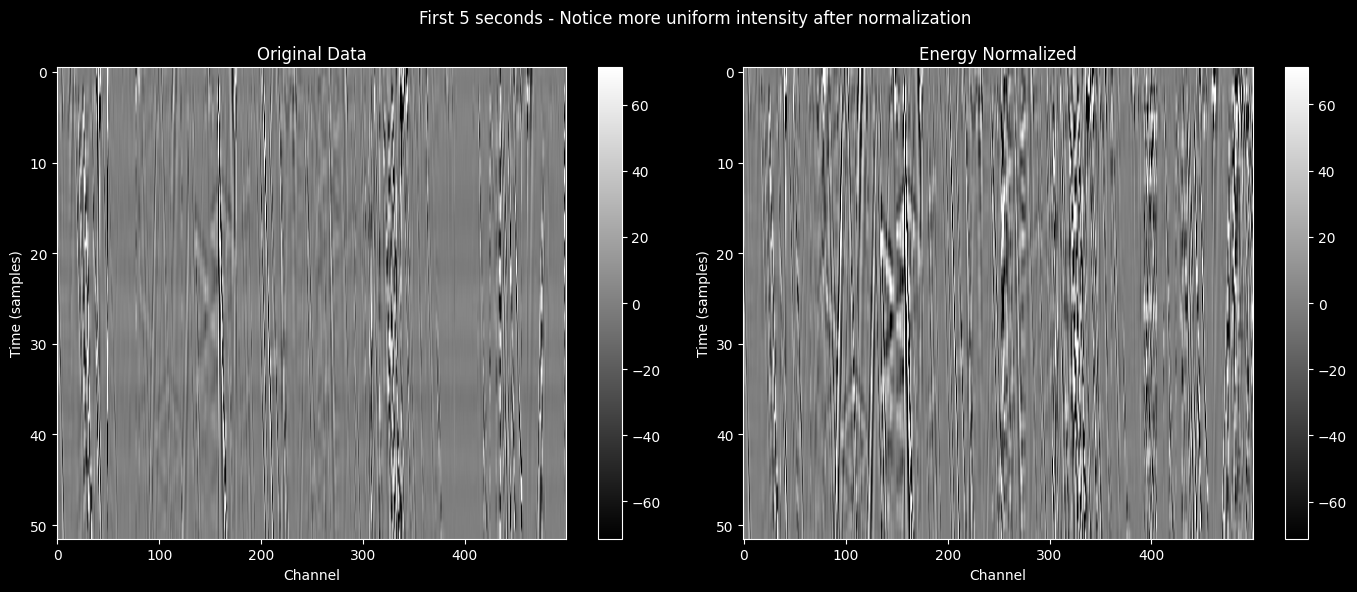

In [745]:
# =============================================================================
# VISUALIZATION: Original vs Normalized Data
# =============================================================================

if CONFIG['energy_normalize'] and selected_data_original is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    vmax_orig = 2 * selected_data_original.std()
    vmax_norm = 2 * selected_data.std()
    n_samples_5sec = int(5 * fs)
    
    # Original data (first 5 seconds)
    ax = axes[0]
    im = ax.imshow(selected_data_original[:, :n_samples_5sec].T, aspect='auto', 
                   cmap='gray', vmin=-vmax_orig, vmax=vmax_orig)
    ax.set_xlabel('Channel')
    ax.set_ylabel('Time (samples)')
    ax.set_title('Original Data')
    plt.colorbar(im, ax=ax)
    
    # Normalized data
    ax = axes[1]
    im = ax.imshow(selected_data[:, :n_samples_5sec].T, aspect='auto',
                   cmap='gray', vmin=-vmax_norm, vmax=vmax_norm)
    ax.set_xlabel('Channel')
    ax.set_ylabel('Time (samples)')
    ax.set_title('Energy Normalized')
    plt.colorbar(im, ax=ax)
    
    plt.suptitle('First 5 seconds - Notice more uniform intensity after normalization', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Energy normalization disabled - skipping comparison visualization")

In [746]:
# =============================================================================
# LOAD DTAN MODEL
# =============================================================================
# DTAN (Diffeomorphic Temporal Alignment Network) learns to time-warp channels
# to align them. If channels correlate well after alignment -> vehicle detected.
# The warp amount encodes vehicle speed.

Nch = CONFIG['Nch']
window_samples = int(CONFIG['window_seconds'] * fs)

# Model configuration (must match training)
class ModelConfig:
    tess_size = 20              # Warping function control points
    N_channels = 1
    Nch = Nch
    signal_length = window_samples
    input_shape = window_samples
    n_recurrences = 1
    bidirectional_RNN = True
    zero_boundary = False
    device = 'cpu'
    device_name = 'cpu'
    fs = fs
    gauge = gauge
    batch_size = 20

model_config = ModelConfig()

# Build and load model
model = DTAN(
    signal_len=model_config.input_shape,
    Nch=model_config.Nch,
    channels=model_config.N_channels,
    tess_size=[model_config.tess_size],
    n_recurrence=model_config.n_recurrences,
    bidirectional_RNN=model_config.bidirectional_RNN,
    zero_boundary=model_config.zero_boundary,
    device=model_config.device,
    device_name=model_config.device_name
)

checkpoint_path = os.path.join(ref_dir, 'models', CONFIG['model_checkpoint'])
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
model.load_state_dict(checkpoint)
model.eval()
T = model.T

print(f"Model loaded: {CONFIG['model_checkpoint']}")
print(f"Input window: {Nch} channels × {window_samples} samples ({CONFIG['window_seconds']}s)")

# Create processor (wraps model with GLRT computation and speed estimation)
processor = SpeedVehicules(
    model=model,
    T=T,
    model_args=model_config,
    ovr_time=1/6,
    glrt_win=CONFIG['glrt_window'],
    min_speed=CONFIG['min_speed'],
    max_speed=CONFIG['max_speed'],
    corr_threshold=CONFIG['corr_threshold'],
    verbose=False
)
print(f"Processor ready. Speed range: {CONFIG['min_speed']}-{CONFIG['max_speed']} km/h")

Model loaded: allignment_parameters_16_02_2026_fullSet_28s.pth
Input window: 9 channels × 291 samples (28s)
Processor ready. Speed range: 20-120 km/h


In [ ]:
# =============================================================================
# PROCESS ALL SPATIAL POSITIONS (with optional bidirectional detection)
# =============================================================================

from tqdm import tqdm

n_spatial = selected_data.shape[0] - Nch + 1  # Number of 9-channel windows that fit
n_time_total = selected_data.shape[1]

# Center the data
data_centered = selected_data - selected_data.mean(axis=1, keepdims=True)

# Edge trimming (matches production: GLRT_EDGE_SAFETY_SAMPLES + glrt_window//2)
EDGE_TRIM = 15 + CONFIG['glrt_window'] // 2  # = 25 samples at 10.4Hz ≈ 2.4s

def process_direction(data_input, desc_prefix=""):
    """Process data in one direction, returns (glrt, speed) arrays."""
    if CONFIG['processing_mode'] == 'single_window':
        time_start_s = CONFIG['time_start_s']
        t_start = int(time_start_s * fs)
        t_end = t_start + window_samples
        if t_end > n_time_total:
            t_start = n_time_total - window_samples
            t_end = n_time_total

        time_slice = data_input[:, t_start:t_end].copy()
        
        results = []
        for i in tqdm(range(n_spatial), desc=f"{desc_prefix}Spatial positions"):
            window_9ch = time_slice[i:i+Nch, :]
            window_dates = np.arange(window_9ch.shape[1]) / fs
            result = processor.process_one_file(window_9ch, window_dates)
            results.append(result)

        glrt = np.zeros((n_spatial, window_samples))
        speed = np.full((n_spatial, window_samples), np.nan)

        for i, r in enumerate(results):
            glrt[i, :] = np.sum(r['glrt_res'][0], axis=0)
            with np.errstate(all='ignore'):
                speed[i, :] = np.nanmedian(r['filtered_speed'][0], axis=0)

        return glrt, speed, t_start, t_end, time_slice

    else:  # sliding_hop
        hop_samples = int(window_samples * CONFIG['hop_fraction'])
        n_time_windows = (n_time_total - window_samples) // hop_samples + 1

        # Edge trimming - exclude degraded samples at window boundaries
        valid_start = EDGE_TRIM
        valid_end = window_samples - EDGE_TRIM

        glrt = np.zeros((n_spatial, n_time_total))
        speed = np.full((n_spatial, n_time_total), np.nan)

        for t_idx in tqdm(range(n_time_windows), desc=f"{desc_prefix}Time windows"):
            t_start_win = t_idx * hop_samples
            t_end_win = t_start_win + window_samples
            if t_end_win > n_time_total:
                break

            time_slice_win = data_input[:, t_start_win:t_end_win]

            for s_idx in range(n_spatial):
                window_9ch = time_slice_win[s_idx:s_idx+Nch, :]
                window_dates = np.arange(window_9ch.shape[1]) / fs
                result = processor.process_one_file(window_9ch, window_dates)

                glrt_sum = np.sum(result['glrt_res'][0], axis=0)
                speed_med = np.nanmedian(result['filtered_speed'][0], axis=0)

                # Map valid zone to absolute indices
                abs_start = t_start_win + valid_start
                abs_end = t_start_win + valid_end

                # Take max GLRT in overlap regions (not average)
                glrt[s_idx, abs_start:abs_end] = np.maximum(
                    glrt[s_idx, abs_start:abs_end],
                    glrt_sum[valid_start:valid_end]
                )

                # Keep first valid speed estimate
                for t in range(valid_start, valid_end):
                    t_abs = t_start_win + t
                    if not np.isnan(speed_med[t]) and np.isnan(speed[s_idx, t_abs]):
                        speed[s_idx, t_abs] = speed_med[t]

        return glrt, speed, 0, n_time_total, data_input

# --- Forward pass ---
print(f"Mode: {CONFIG['processing_mode'].upper()}")
if CONFIG['processing_mode'] == 'sliding_hop':
    print(f"Edge trimming: {EDGE_TRIM} samples (~{EDGE_TRIM/fs:.1f}s) per side")
full_glrt_fwd, full_speed_fwd, t_start, t_end, time_slice = process_direction(data_centered, "Forward: ")

# --- Reverse pass (if bidirectional) ---
if CONFIG['bidirectional']:
    data_flipped = data_centered[::-1, :].copy()
    full_glrt_rev, full_speed_rev, _, _, _ = process_direction(data_flipped, "Reverse: ")
    
    # Flip results back to original spatial order
    full_glrt_rev = full_glrt_rev[::-1, :].copy()
    full_speed_rev = full_speed_rev[::-1, :].copy()
else:
    full_glrt_rev = None
    full_speed_rev = None

# --- Combine results ---
if CONFIG['bidirectional']:
    # Create direction mask: 0=none, 1=forward, 2=reverse, 3=both
    fwd_det = full_glrt_fwd >= threshold_fwd
    rev_det = full_glrt_rev >= threshold_rev
    direction_mask = fwd_det.astype(int) + 2 * rev_det.astype(int)
    
    # Combined GLRT: take max from either direction
    full_glrt = np.maximum(full_glrt_fwd, full_glrt_rev)
    
    # Combined speed: use speed from direction with higher GLRT
    full_speed = np.where(full_glrt_fwd >= full_glrt_rev, full_speed_fwd, full_speed_rev)
    
    # Use combined threshold (detection if either direction exceeds its threshold)
    detection_mask = fwd_det | rev_det
    
    # Stats
    n_fwd = np.sum(fwd_det)
    n_rev = np.sum(rev_det)
    n_both = np.sum(fwd_det & rev_det)
    n_combined = np.sum(detection_mask)
    
    print(f"\nBidirectional Detection Results:")
    print(f"  Forward only:  {n_fwd - n_both:,}")
    print(f"  Reverse only:  {n_rev - n_both:,}")
    print(f"  Both dirs:     {n_both:,}")
    print(f"  Total:         {n_combined:,}")
else:
    full_glrt = full_glrt_fwd
    full_speed = full_speed_fwd
    detection_mask = full_glrt >= threshold_fwd
    direction_mask = detection_mask.astype(int)  # 0=none, 1=forward

# Build time axis
if CONFIG['processing_mode'] == 'single_window':
    n_time = window_samples
    time_axis_full = np.arange(n_time) / fs + t_start/fs
else:
    n_time = n_time_total
    time_axis_full = np.arange(n_time_total) / fs

# For compatibility, also compute hop_samples for sliding_hop mode
if CONFIG['processing_mode'] == 'sliding_hop':
    hop_samples = int(window_samples * CONFIG['hop_fraction'])
    n_time_windows = (n_time_total - window_samples) // hop_samples + 1

# Mask speeds to only show where detections occurred
full_speed_masked = np.where(detection_mask, full_speed, np.nan)

print(f"Done! Shape: {full_glrt.shape}")

Mode: SLIDING_HOP
Edge trimming: 25 samples (~2.4s) per side


Forward: Time windows:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
# =============================================================================
# EXTRACT DETECTION INTERVALS
# =============================================================================
# Find contiguous runs where GLRT exceeds threshold, compute median speed per interval.
# 
# Edge trimming: The first/last samples of each interval often have poor alignment
# and unreliable speed estimates (the ~30 km/h artifacts). We trim them.

from modules.utils import find_ind_optimised

center_offset = Nch // 2  # GLRT represents center channel of 9-ch window

# Distance axis (km) for center channel of each window
dist_axis_full = (np.arange(n_spatial) + FIBER['channel_start'] + center_offset) * gauge / 1000

# Temporal edge trim for speed estimation (samples to skip at start/end of each interval)
# At ~10 Hz, 2 samples ≈ 0.2s - enough to skip the edge artifacts
INTERVAL_EDGE_TRIM = 2

# Extract intervals per spatial position
intervals_data = []
for s_idx in range(n_spatial):
    row_mask = detection_mask[s_idx, :].astype(int)
    starts, ends = find_ind_optimised(row_mask)

    for int_start, int_end in zip(starts, ends):
        interval_length = int_end - int_start
        
        # Apply edge trimming for speed estimation (but keep full interval bounds)
        trim_start = int_start + min(INTERVAL_EDGE_TRIM, interval_length // 3)
        trim_end = int_end - min(INTERVAL_EDGE_TRIM, interval_length // 3)
        
        if trim_start >= trim_end:
            # Interval too short after trimming, use original
            trim_start = int_start
            trim_end = int_end
        
        # Get speeds from trimmed region (avoiding edge artifacts)
        interval_speeds = full_speed_masked[s_idx, trim_start:trim_end]
        valid_speeds = interval_speeds[~np.isnan(interval_speeds)]

        if len(valid_speeds) > 0:
            # Determine dominant direction for this interval
            if CONFIG['bidirectional']:
                dir_vals = direction_mask[s_idx, int_start:int_end]
                # Count: 1=fwd, 2=rev, 3=both
                n_fwd_only = np.sum(dir_vals == 1)
                n_rev_only = np.sum(dir_vals == 2)
                n_both = np.sum(dir_vals == 3)
                
                if n_both > max(n_fwd_only, n_rev_only):
                    direction = 'both'
                elif n_fwd_only > n_rev_only:
                    direction = 'forward'
                else:
                    direction = 'reverse'
            else:
                direction = 'forward'
            
            intervals_data.append({
                'spatial_idx': s_idx,
                'dist_km': dist_axis_full[s_idx],
                't_start': time_axis_full[int_start],
                't_end': time_axis_full[min(int_end-1, len(time_axis_full)-1)],
                't_mid': (time_axis_full[int_start] + time_axis_full[min(int_end-1, len(time_axis_full)-1)]) / 2,
                'speed': np.median(valid_speeds),
                'duration': (int_end - int_start) / fs,
                'direction': direction,
            })

print(f"Extracted {len(intervals_data)} detection intervals")
print(f"Interval edge trim: {INTERVAL_EDGE_TRIM} samples (~{INTERVAL_EDGE_TRIM/fs:.2f}s) for speed estimation")
if len(intervals_data) > 0:
    speeds = [d['speed'] for d in intervals_data]
    print(f"Speed statistics: mean={np.mean(speeds):.1f}, median={np.median(speeds):.1f}, std={np.std(speeds):.1f} km/h")
    
    if CONFIG['bidirectional']:
        n_fwd = sum(1 for d in intervals_data if d['direction'] == 'forward')
        n_rev = sum(1 for d in intervals_data if d['direction'] == 'reverse')
        n_both = sum(1 for d in intervals_data if d['direction'] == 'both')
        print(f"By direction: {n_fwd} forward, {n_rev} reverse, {n_both} both")

In [ ]:
# =============================================================================
# MAIN VISUALIZATION: Waterfall with Detections
# =============================================================================

if CONFIG['processing_mode'] == 'single_window':
    waterfall_data = time_slice[center_offset:center_offset + n_spatial, :]
else:
    waterfall_data = data_centered[center_offset:center_offset + n_spatial, :]

fig, axes = plt.subplots(1, 3, figsize=(18, 10))
waterfall = waterfall_data.T  # Transpose for imshow (time on Y, distance on X)
vmax = 2 * waterfall_data.std()

# Panel 1: Raw waterfall
ax = axes[0]
im = ax.imshow(waterfall, aspect='auto',
               extent=[dist_axis_full[0], dist_axis_full[-1], time_axis_full[-1], time_axis_full[0]],
               cmap='gray', vmin=-vmax, vmax=vmax)
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Time (s)')
ax.set_title('Raw Waterfall')
plt.colorbar(im, ax=ax, label='Amplitude')

# Panel 2: Detections colored by direction
ax = axes[1]
im = ax.imshow(waterfall, aspect='auto',
               extent=[dist_axis_full[0], dist_axis_full[-1], time_axis_full[-1], time_axis_full[0]],
               cmap='gray', vmin=-vmax, vmax=vmax)

if CONFIG['bidirectional'] and len(intervals_data) > 0:
    # Color by direction: green=forward, red=reverse, yellow=both
    dir_colors = {'forward': 'lime', 'reverse': 'red', 'both': 'yellow'}
    for direction in ['forward', 'reverse', 'both']:
        subset = [d for d in intervals_data if d['direction'] == direction]
        if subset:
            dists = [d['dist_km'] for d in subset]
            times = [d['t_mid'] for d in subset]
            ax.scatter(dists, times, c=dir_colors[direction], s=8, alpha=0.7, 
                       label=f'{direction.capitalize()} ({len(subset)})', edgecolors='k', linewidths=0.2)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_title(f'Detections by Direction (n={len(intervals_data)})')
else:
    for d in intervals_data:
        ax.plot(d['dist_km'], d['t_mid'], 'g.', markersize=3, alpha=0.8)
    ax.set_title(f'Detections (n={len(intervals_data)}, thr={threshold_fwd})')
    
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Time (s)')
plt.colorbar(im, ax=ax, label='Amplitude')

# Panel 3: Speed overlay (color-coded)
ax = axes[2]
im = ax.imshow(waterfall, aspect='auto',
               extent=[dist_axis_full[0], dist_axis_full[-1], time_axis_full[-1], time_axis_full[0]],
               cmap='gray', vmin=-vmax, vmax=vmax)
if len(intervals_data) > 0:
    dists = [d['dist_km'] for d in intervals_data]
    times = [d['t_mid'] for d in intervals_data]
    speeds = [d['speed'] for d in intervals_data]
    sc = ax.scatter(dists, times, c=speeds, cmap='jet',
                    vmin=CONFIG['min_speed'], vmax=CONFIG['max_speed'],
                    s=15, alpha=0.9, edgecolors='k', linewidths=0.3)
    plt.colorbar(sc, ax=ax, label='Speed (km/h)')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Time (s)')
ax.set_title('Speed at Interval Centers')

mode_label = CONFIG['processing_mode'].replace('_', ' ').title()
bidir_label = " (Bidirectional)" if CONFIG['bidirectional'] else ""
duration = time_axis_full[-1] - time_axis_full[0]
plt.suptitle(f'{CONFIG["fiber"]} - {mode_label}{bidir_label} - {duration:.1f}s', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SPEED DISTRIBUTION & STATISTICS
# =============================================================================

if len(intervals_data) > 0:
    speeds = [d['speed'] for d in intervals_data]

    if CONFIG['bidirectional']:
        # Split by direction
        speeds_fwd = [d['speed'] for d in intervals_data if d['direction'] == 'forward']
        speeds_rev = [d['speed'] for d in intervals_data if d['direction'] == 'reverse']
        speeds_both = [d['speed'] for d in intervals_data if d['direction'] == 'both']
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        
        # Stacked histogram by direction
        ax = axes[0]
        bins = np.linspace(CONFIG['min_speed'], CONFIG['max_speed'], 21)
        ax.hist([speeds_fwd, speeds_rev, speeds_both], bins=bins, 
                label=[f'Forward ({len(speeds_fwd)})', f'Reverse ({len(speeds_rev)})', f'Both ({len(speeds_both)})'],
                color=['lime', 'red', 'yellow'], edgecolor='black', alpha=0.7, stacked=True)
        ax.axvline(np.mean(speeds), color='blue', ls='--', lw=2, label=f'Mean: {np.mean(speeds):.1f}')
        ax.set_xlabel('Speed (km/h)')
        ax.set_ylabel('Count')
        ax.set_title('Speed Distribution by Direction')
        ax.legend(fontsize=8)

        # Speed vs distance colored by direction
        ax = axes[1]
        dir_colors = {'forward': 'lime', 'reverse': 'red', 'both': 'yellow'}
        for direction in ['forward', 'reverse', 'both']:
            subset = [d for d in intervals_data if d['direction'] == direction]
            if subset:
                dists = [d['dist_km'] for d in subset]
                spds = [d['speed'] for d in subset]
                ax.scatter(dists, spds, c=dir_colors[direction], alpha=0.5, s=20, 
                           label=direction.capitalize(), edgecolors='k', linewidths=0.2)
        ax.axhline(np.median(speeds), color='blue', ls='--', alpha=0.5)
        ax.set_xlabel('Distance (km)')
        ax.set_ylabel('Speed (km/h)')
        ax.set_title('Speed vs Position')
        ax.set_ylim([CONFIG['min_speed']-10, CONFIG['max_speed']+10])
        ax.legend(fontsize=8)
        
        # Direction breakdown pie chart
        ax = axes[2]
        dir_counts = [len(speeds_fwd), len(speeds_rev), len(speeds_both)]
        dir_labels = ['Forward', 'Reverse', 'Both']
        dir_colors_list = ['lime', 'red', 'yellow']
        ax.pie(dir_counts, labels=dir_labels, colors=dir_colors_list, autopct='%1.1f%%', 
               startangle=90, explode=[0.02, 0.02, 0.02])
        ax.set_title('Detection Direction Breakdown')
        
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Speed histogram
        ax = axes[0]
        ax.hist(speeds, bins=20, edgecolor='black', alpha=0.7)
        ax.axvline(np.mean(speeds), color='red', ls='--', label=f'Mean: {np.mean(speeds):.1f}')
        ax.axvline(np.median(speeds), color='green', ls='--', label=f'Median: {np.median(speeds):.1f}')
        ax.set_xlabel('Speed (km/h)')
        ax.set_ylabel('Count')
        ax.set_title('Speed Distribution')
        ax.legend()

        # Speed vs distance
        ax = axes[1]
        dists = [d['dist_km'] for d in intervals_data]
        ax.scatter(dists, speeds, alpha=0.5, s=20)
        ax.axhline(np.median(speeds), color='green', ls='--', alpha=0.5)
        ax.set_xlabel('Distance (km)')
        ax.set_ylabel('Speed (km/h)')
        ax.set_title('Speed vs Position')
        ax.set_ylim([CONFIG['min_speed']-10, CONFIG['max_speed']+10])

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print("DETECTION SUMMARY")
    print(f"{'='*50}")
    print(f"Total detections: {len(intervals_data)}")
    print(f"Speed range: {min(speeds):.1f} - {max(speeds):.1f} km/h")
    print(f"Mean speed: {np.mean(speeds):.1f} km/h")
    print(f"Median speed: {np.median(speeds):.1f} km/h")
    print(f"Std dev: {np.std(speeds):.1f} km/h")
    
    if CONFIG['bidirectional']:
        print(f"\nBy direction:")
        print(f"  Forward: {len(speeds_fwd)} ({100*len(speeds_fwd)/len(intervals_data):.1f}%)")
        print(f"  Reverse: {len(speeds_rev)} ({100*len(speeds_rev)/len(intervals_data):.1f}%)")
        print(f"  Both:    {len(speeds_both)} ({100*len(speeds_both)/len(intervals_data):.1f}%)")
else:
    print("No detections found. Try lowering CONFIG['corr_threshold'].")

## Deep Dive: Inspect Single Detection

Inspect a single detection to understand the alignment and GLRT computation:
1. **Unaligned vs Aligned**: How DTAN warps the 9 channels
2. **GLRT per pair**: Correlation score for each adjacent channel pair
3. **Threshold crossing**: How detections are triggered

In [ ]:
# =============================================================================
# INSPECT SINGLE DETECTION - Alignment Visualization
# =============================================================================

if len(intervals_data) == 0:
    print("No detections to inspect!")
else:
    INSPECT_IDX = 0  # Change to inspect different detections
    selected = intervals_data[min(INSPECT_IDX, len(intervals_data)-1)]
    inspect_s = selected['spatial_idx']

    print(f"Inspecting detection {INSPECT_IDX + 1} of {len(intervals_data)}:")
    print(f"  Position: {selected['dist_km']:.3f} km (spatial idx {inspect_s})")
    print(f"  Time: {selected['t_start']:.2f} - {selected['t_end']:.2f} s")
    print(f"  Speed: {selected['speed']:.1f} km/h")

    # Extract window centered on detection
    det_time_idx = int(selected['t_mid'] * fs)
    inspect_t_start = max(0, det_time_idx - window_samples // 2)
    inspect_t_end = inspect_t_start + window_samples
    if inspect_t_end > n_time_total:
        inspect_t_end = n_time_total
        inspect_t_start = inspect_t_end - window_samples

    window_9ch = data_centered[inspect_s:inspect_s+Nch, inspect_t_start:inspect_t_end]
    window_dates = np.arange(window_9ch.shape[1]) / fs

    # Process to get alignment
    result = processor.process_one_file(window_9ch, window_dates)
    aligned = result['aligned'][0]
    glrt = result['glrt_res'][0]
    filtered_speed = result['filtered_speed'][0]

    # Plot unaligned vs aligned
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor='black')
    t = np.arange(window_9ch.shape[1]) / fs
    offset = 3.5 * window_9ch.std()
    center_ch = Nch // 2

    colors = [plt.cm.plasma(i/(Nch-1)) for i in range(Nch)]
    colors[center_ch] = 'yellow'

    # Unaligned
    ax = axes[0]
    ax.set_facecolor('black')
    for ch in range(Nch):
        lw = 1.2 if ch == center_ch else 0.7
        ax.plot(t, window_9ch[ch] - offset*ch, color=colors[ch], lw=lw)
    ax.set_xlabel('Time (s)', color='white')
    ax.set_ylabel('Channel', color='white')
    ax.set_title('UNALIGNED - Original 9 Channels', color='lime', fontsize=14)
    ax.tick_params(colors='white')
    ax.set_yticks([-offset*ch for ch in range(Nch)])
    ax.set_yticklabels([f'Ch{ch}' for ch in range(Nch)])

    # Aligned
    ax = axes[1]
    ax.set_facecolor('black')
    for ch in range(Nch):
        lw = 1.2 if ch == center_ch else 0.7
        ax.plot(t, aligned[ch] - offset*ch, color=colors[ch], lw=lw)
    ax.set_xlabel('Time (s)', color='white')
    ax.set_title('ALIGNED - Warped to center (ch4)', color='lime', fontsize=14)
    ax.tick_params(colors='white')
    ax.set_yticks([-offset*ch for ch in range(Nch)])
    ax.set_yticklabels([f'Ch{ch}' for ch in range(Nch)])

    plt.suptitle(f'Detection at {selected["t_mid"]:.1f}s - channels should align after DTAN warping', 
                 color='white', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
# =============================================================================
# GLRT COMPUTATION VISUALIZATION
# =============================================================================
# Shows GLRT per channel pair, sum vs threshold, and speed estimates.

if len(intervals_data) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    t = np.arange(window_9ch.shape[1]) / fs

    # Panel 1: GLRT per channel pair
    ax = axes[0]
    glrt_offset = np.max(np.abs(glrt)) * 1.2
    for ch in range(Nch-1):
        ax.plot(t, glrt[ch] - glrt_offset*ch,
                color=plt.cm.plasma(ch/(Nch-2)), lw=0.8,
                label=f'Ch{ch}-Ch{ch+1}')
    ax.set_ylabel('GLRT (offset)')
    ax.set_title('GLRT per Adjacent Channel Pair (8 pairs)')
    ax.legend(loc='upper right', ncol=4, fontsize=8)
    ax.set_xlim([t[0], t[-1]])

    # Panel 2: GLRT sum with threshold
    ax = axes[1]
    lambda_stat = np.sum(glrt, axis=0)
    ax.fill_between(t, 0, lambda_stat, alpha=0.3, color='blue')
    ax.plot(t, lambda_stat, 'b-', lw=1)
    ax.axhline(threshold_fwd, color='red', ls='--', lw=2, label=f'Threshold ({threshold_fwd})')

    detection_mask_win = lambda_stat >= threshold_fwd
    ax.fill_between(t, 0, lambda_stat, where=detection_mask_win,
                    color='orange', alpha=0.7, label='Detections')

    ax.set_ylabel('GLRT Sum')
    ax.set_title('Sum Across All Channel Pairs')
    ax.legend(loc='upper right')
    ax.set_xlim([t[0], t[-1]])

    # Panel 3: Speed at detection points
    ax = axes[2]
    median_speed = np.nanmedian(filtered_speed, axis=0)
    scatter_t = t[detection_mask_win]
    scatter_speed = median_speed[detection_mask_win]
    valid_mask = ~np.isnan(scatter_speed)

    if valid_mask.any():
        sc = ax.scatter(scatter_t[valid_mask], scatter_speed[valid_mask],
                        c=scatter_speed[valid_mask], cmap='jet',
                        vmin=CONFIG['min_speed'], vmax=CONFIG['max_speed'],
                        s=50, alpha=0.8, edgecolors='k', linewidths=0.5)
        plt.colorbar(sc, ax=ax, label='Speed (km/h)')

    ax.axhline(CONFIG['min_speed'], color='gray', ls=':', label='Speed limits')
    ax.axhline(CONFIG['max_speed'], color='gray', ls=':')
    ax.set_ylim([0, CONFIG['max_speed'] + 20])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Speed (km/h)')
    ax.set_title('Estimated Vehicle Speeds')
    ax.set_xlim([t[0], t[-1]])

    plt.suptitle(f'GLRT Detection Pipeline - Position {inspect_s} ({selected["dist_km"]:.3f} km)', fontsize=14)
    plt.tight_layout()
    plt.show()

    n_det = np.sum(detection_mask_win)
    print(f"\nDetection stats for this position:")
    print(f"  Detection points: {n_det} / {len(t)} ({100*n_det/len(t):.1f}%)")
else:
    print("No detections to visualize")

In [ ]:
# =============================================================================
# VEHICLE COUNTING SETUP
# =============================================================================
# Vehicle counting is done at a specific spatial section (point on the fiber).
# This matches visualize_data.ipynb which processes ONE 9-channel window.
#
# The VehicleCounter class below is kept for potential future DL mode support,
# but the primary counting is done via count_vehicles_at_section_lambda() in the next cell.

from scipy.signal import find_peaks

# Note: The actual counting logic is in the next cell.
# This cell just imports find_peaks and sets up the counter flag.

if CONFIG.get('enable_counting', False):
    print(f"Vehicle counting: ENABLED")
    print(f"  Mode: {CONFIG.get('counting_mode', 'lambda')}")
    print(f"  Counting will be performed at a representative spatial section")
else:
    print("Vehicle counting: DISABLED")

In [ ]:
# =============================================================================
# RUN VEHICLE COUNTING
# =============================================================================
#
# Goal: For each detection interval (position + time), count how many vehicles.
# 
# Each entry in intervals_data has:
#   - spatial_idx, dist_km (position)
#   - t_start, t_end (time)
#   - speed, direction (from detection)
#
# We add: vehicle_count, n_cars, n_trucks

from scipy.signal import find_peaks

def count_peaks_in_segment(glrt_segment, threshold, fs, classify_threshold):
    """Count vehicle peaks within a GLRT segment.
    
    Args:
        glrt_segment: 1D array of GLRT values
        threshold: Detection threshold
        fs: Sample rate
        classify_threshold: Threshold for truck classification
    
    Returns:
        (n_vehicles, n_cars, n_trucks)
    """
    if len(glrt_segment) == 0:
        return 0, 0, 0
    
    # Peak detection parameters
    min_peak_distance = max(1, int(0.25 * fs))  # Min 0.25s between peaks
    min_prominence = max(1.0, 0.1 * threshold)
    
    peaks, props = find_peaks(
        glrt_segment,
        height=threshold,
        distance=min_peak_distance,
        prominence=min_prominence
    )
    
    if len(peaks) == 0:
        # No distinct peaks - check if signal exceeds threshold at all
        if np.nanmax(glrt_segment) >= threshold:
            if np.nanmax(glrt_segment) >= classify_threshold:
                return 1, 0, 1  # 1 truck
            else:
                return 1, 1, 0  # 1 car
        return 0, 0, 0
    
    n_vehicles = len(peaks)
    peak_heights = props.get("peak_heights", np.array([]))
    n_trucks = int(np.sum(peak_heights >= classify_threshold))
    n_cars = n_vehicles - n_trucks
    
    return n_vehicles, n_cars, n_trucks


if CONFIG.get('enable_counting', False) and len(intervals_data) > 0:
    classify_thr = threshold_fwd * CONFIG.get('classify_threshold_factor', 10.0)
    
    print(f"{'='*60}")
    print("VEHICLE COUNTING")
    print(f"{'='*60}")
    print(f"Detection threshold: {threshold_fwd}")
    print(f"Classification threshold (truck): {classify_thr:.0f}")
    print(f"Intervals to process: {len(intervals_data)}")
    print()
    
    # Count vehicles in each interval
    for interval in intervals_data:
        s_idx = interval['spatial_idx']
        t_start_idx = int(interval['t_start'] * fs)
        t_end_idx = int(interval['t_end'] * fs) + 1
        
        # Clamp to valid range
        t_start_idx = max(0, t_start_idx)
        t_end_idx = min(full_glrt.shape[1], t_end_idx)
        
        # Get GLRT segment for this interval
        glrt_segment = full_glrt[s_idx, t_start_idx:t_end_idx]
        
        # Count peaks
        n_veh, n_cars, n_trucks = count_peaks_in_segment(
            glrt_segment, threshold_fwd, fs, classify_thr
        )
        
        interval['vehicle_count'] = n_veh
        interval['n_cars'] = n_cars
        interval['n_trucks'] = n_trucks
    
    # Summary statistics
    total_vehicles = sum(d['vehicle_count'] for d in intervals_data)
    total_cars = sum(d['n_cars'] for d in intervals_data)
    total_trucks = sum(d['n_trucks'] for d in intervals_data)
    
    # Count intervals by vehicle count
    single_vehicle = sum(1 for d in intervals_data if d['vehicle_count'] == 1)
    multi_vehicle = sum(1 for d in intervals_data if d['vehicle_count'] > 1)
    zero_vehicle = sum(1 for d in intervals_data if d['vehicle_count'] == 0)
    
    print(f"Results:")
    print(f"  Total intervals: {len(intervals_data)}")
    print(f"    - 0 vehicles: {zero_vehicle}")
    print(f"    - 1 vehicle: {single_vehicle}")
    print(f"    - 2+ vehicles: {multi_vehicle}")
    print()
    print(f"  Total vehicle detections: {total_vehicles}")
    print(f"    - Cars: {total_cars} ({100*total_cars/max(1,total_vehicles):.1f}%)")
    print(f"    - Trucks: {total_trucks} ({100*total_trucks/max(1,total_vehicles):.1f}%)")
    print()
    
    # NOTE: This total is NOT the number of unique vehicles!
    # A single vehicle passing creates ~100+ intervals as it travels along the fiber.
    # The count tells you "how many vehicles in this specific (position, time) box"
    
    # Show sample intervals with counts
    print("Sample intervals with vehicle counts:")
    sample = [d for d in intervals_data if d['vehicle_count'] > 0][:10]
    for d in sample:
        print(f"  {d['dist_km']:.2f} km, t={d['t_start']:.1f}-{d['t_end']:.1f}s: "
              f"{d['vehicle_count']} vehicles (cars={d['n_cars']}, trucks={d['n_trucks']}), "
              f"speed={d['speed']:.0f} km/h, dir={d['direction']}")
    
    # To estimate UNIQUE vehicles, look at one representative section
    print()
    print("=" * 40)
    print("UNIQUE VEHICLE ESTIMATE (at middle section)")
    print("=" * 40)
    mid_section = n_spatial // 2
    mid_intervals = [d for d in intervals_data if d['spatial_idx'] == mid_section]
    unique_vehicles = sum(d['vehicle_count'] for d in mid_intervals)
    unique_cars = sum(d['n_cars'] for d in mid_intervals)
    unique_trucks = sum(d['n_trucks'] for d in mid_intervals)
    
    duration_s = full_glrt.shape[1] / fs
    print(f"At section {mid_section} ({dist_axis_full[mid_section]:.2f} km):")
    print(f"  {len(mid_intervals)} intervals, {unique_vehicles} vehicles")
    print(f"  Cars: {unique_cars}, Trucks: {unique_trucks}")
    print(f"  Rate: {unique_vehicles / (duration_s / 60):.1f} vehicles/min")

else:
    total_vehicles = 0
    total_cars = 0
    total_trucks = 0
    
    if not CONFIG.get('enable_counting', False):
        print("Vehicle counting: DISABLED")
    else:
        print("No intervals to count")

In [ ]:
# =============================================================================
# COUNTING VISUALIZATION
# =============================================================================

if CONFIG.get('enable_counting', False) and len(intervals_data) > 0 and total_vehicles > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Panel 1: Waterfall with vehicle counts overlaid
    ax = axes[0]
    waterfall = data_centered[center_offset:center_offset + n_spatial, :].T
    vmax = 2 * waterfall.std()
    
    ax.imshow(waterfall, aspect='auto',
              extent=[dist_axis_full[0], dist_axis_full[-1], time_axis_full[-1], time_axis_full[0]],
              cmap='gray', vmin=-vmax, vmax=vmax)
    
    # Overlay intervals colored by vehicle count
    for d in intervals_data:
        if d['vehicle_count'] > 0:
            color = 'lime' if d['vehicle_count'] == 1 else 'yellow' if d['vehicle_count'] == 2 else 'red'
            ax.plot(d['dist_km'], d['t_mid'], '.', color=color, markersize=4, alpha=0.7)
    
    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Time (s)')
    ax.set_title('Detections (green=1, yellow=2, red=3+)')
    
    # Panel 2: Vehicle count distribution
    ax = axes[1]
    counts = [d['vehicle_count'] for d in intervals_data]
    max_count = min(max(counts), 5)  # Cap at 5 for display
    bins = np.arange(0, max_count + 2) - 0.5
    ax.hist(counts, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel('Vehicles per Interval')
    ax.set_ylabel('Number of Intervals')
    ax.set_title('Vehicle Count Distribution')
    ax.set_xticks(range(max_count + 1))
    
    # Panel 3: Cars vs Trucks (at middle section only)
    ax = axes[2]
    mid_section = n_spatial // 2
    mid_intervals = [d for d in intervals_data if d['spatial_idx'] == mid_section]
    unique_cars = sum(d['n_cars'] for d in mid_intervals)
    unique_trucks = sum(d['n_trucks'] for d in mid_intervals)
    
    if unique_cars + unique_trucks > 0:
        sizes = [unique_cars, unique_trucks]
        labels = [f'Cars ({unique_cars})', f'Trucks ({unique_trucks})']
        colors = ['#4CAF50', '#FF5722']
        ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
               startangle=90, explode=[0.02, 0.02])
        ax.set_title(f'Classification at {dist_axis_full[mid_section]:.1f} km')
    else:
        ax.text(0.5, 0.5, 'No vehicles at middle section', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title('Vehicle Classification')
    
    unique_total = unique_cars + unique_trucks
    duration_s = full_glrt.shape[1] / fs
    plt.suptitle(f'Vehicle Counting — {unique_total} unique vehicles at middle section in {duration_s:.0f}s',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

else:
    if not CONFIG.get('enable_counting', False):
        print("Counting visualization skipped: Vehicle counting disabled")
    elif len(intervals_data) == 0:
        print("Counting visualization skipped: No detection intervals")
    else:
        print("Counting visualization skipped: No vehicles detected")